In [1]:
import os
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
import rasterio.transform as rio_transform
from photutils.utils import ShepardIDWInterpolator

In [2]:
data_path = Path(os.environ["DATA_PATH"])

In [3]:
bounds = gpd.read_file(data_path / "lim_aumxl24").to_crs("EPSG:6372")["geometry"].item()

In [4]:
df = gpd.GeoDataFrame(
    pd.read_excel(data_path / "calidad_del_aire.xlsx", sheet_name=1)
    .assign(
        geometry=lambda df: gpd.points_from_xy(df["lng"], df["lat"]),
        date=lambda df: pd.to_datetime(
            df["Año"].astype(str) + "-" + df["Mes"].astype(str) + "-01",
            format="%Y-%m-%d",
        ),
    )
    .rename(columns={"µg/m³": "mug/m3"})
    .drop(columns=["lng", "lat", "Año", "Mes"]),
    crs="EPSG:4326",
    geometry="geometry",
).to_crs("EPSG:6372")

df = df[df.within(bounds)]

Text(0, 0.5, 'Concentración promedio mensual (µg/m³)')

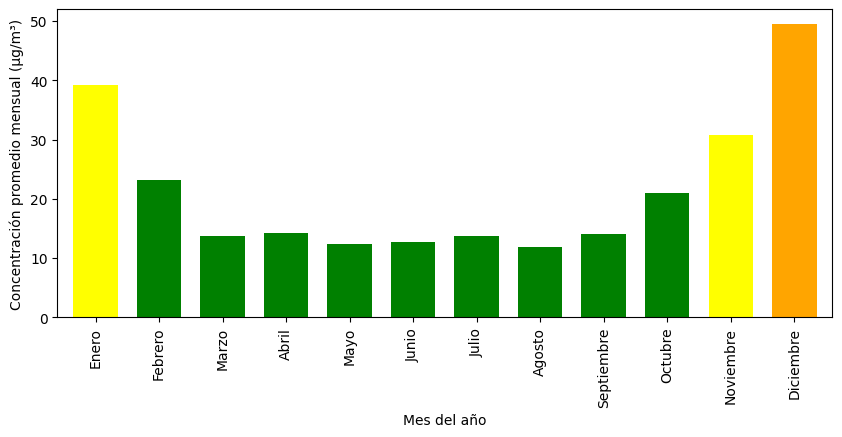

In [ ]:
month_map = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre",
}

# Color map with green, yellow, orange, red, purple
color_map = {1: "green", 2: "yellow", 3: "orange", 4: "red", 5: "purple"}

df_plot = (
    df.query("date.dt.year == 2024")
    .assign(month=lambda df: df["date"].dt.month)
    .groupby("month")["mug/m3"]
    .mean()
    .reset_index()
    .assign(month=lambda df: df["month"].map(month_map))
    .set_index("month")
)

colors = np.digitize(df_plot["mug/m3"], bins=[0, 25, 45, 79, 147, np.inf])

fig, ax = plt.subplots(figsize=(10, 4))
df_plot.plot.bar(
    ax=ax,
    width=0.7,
    legend=False,
    facecolor=[color_map[c] for c in colors],
)
ax.set_xlabel("Mes del año")
ax.set_ylabel("Concentración promedio mensual (µg/m³)")

In [15]:
df_plot.to_csv("./air_quality_month.csv", index=True)

In [5]:
xmin, ymin, xmax, ymax = df.total_bounds

offset = 0.15
xoffset = (xmax - xmin) * offset
yoffset = (ymax - ymin) * offset

xmin -= xoffset
xmax += xoffset
ymin -= yoffset
ymax += yoffset

xrange = np.arange(xmin, xmax, 50)
yrange = np.arange(ymin, ymax, 50)

xx, yy = np.meshgrid(xrange, yrange)

In [ ]:
def get_seasonal_df(df: gpd.GeoDataFrame, year: int) -> gpd.GeoDataFrame:
    season_dates = {
        "winter": (f"{year - 1}-12-01", f"{year}-02-28"),
        "spring": (f"{year}-03-01", f"{year}-05-31"),
        "summer": (f"{year}-06-01", f"{year}-08-31"),
        "fall": (f"{year}-09-01", f"{year}-11-30"),
    }

    df_seasonal = []
    for season in ["winter", "spring", "summer", "fall"]:
        start, end = season_dates[season]
        temp = gpd.GeoDataFrame(
            df.query(
                f"'{start}' <= date <= '{end}'",
            )
            .groupby("idmonitor")
            .agg({"geometry": "first", "mug/m3": "mean"}),
            crs=df.crs,
            geometry="geometry",
        )
        temp = temp.assign(season=season)
        df_seasonal.append(temp)

    return pd.concat(df_seasonal).reset_index().set_index(["season", "idmonitor"])


def interpolate_df(df: gpd.GeoDataFrame) -> np.ndarray:
    final_arr = []
    for season in ["winter", "spring", "summer", "fall"]:
        temp = df.loc[season]
        coords = temp.get_coordinates().to_numpy()
        values = temp["mug/m3"].to_numpy()

        interp = ShepardIDWInterpolator(coords, values)
        res = interp(
            np.vstack([xx.flatten(), yy.flatten()]).T,
            n_neighbors=15,
            power=2,
        ).reshape(xx.shape)

        final_arr.append(res)
    return np.array(final_arr)


def plot_seasons(
    arr: np.ndarray,
    *,
    axes: np.ndarray,
    xmin: float,
    ymin: float,
    xmax: float,
    ymax: float,
    cmap,
    norm,
) -> None:
    for i, season in enumerate(["winter", "spring", "summer", "fall"]):
        ax = axes.flatten()[i]
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        cx.add_basemap(ax=ax, crs=df.crs, source=cx.providers.CartoDB.Positron)

        ax.imshow(
            arr[i],
            cmap=cmap,
            norm=norm,
            extent=(xmin, xmax, ymin, ymax),
            alpha=0.5,
            origin="lower",
        )
        ax.axis("off")
        ax.set_title(season.title())

In [7]:
year_arrs = []
for year in [2023, 2024]:
    temp = get_seasonal_df(df, year)
    year_arrs.append(interpolate_df(temp))
year_arrs = np.array(year_arrs)

In [8]:
bins = [0, 25, 45, 79, 147]
year_arrs_digitized = np.digitize(
    year_arrs.mean(axis=0),
    bins=bins,
)

NameError: name 'cmap' is not defined

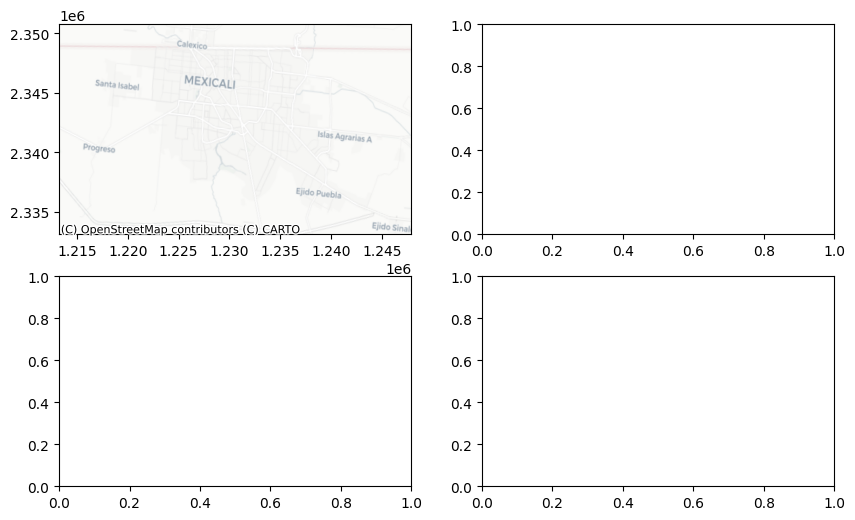

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))
plot_seasons(year_arrs_digitized, axes=ax, xmin=xmin, ymin=ymin, xmax=xmax, ymax=ymax)
fig.tight_layout()

In [11]:
transform = rio_transform.from_bounds(
    xmin,
    ymin,
    xmax,
    ymax,
    width=year_arrs_digitized.shape[2],
    height=year_arrs_digitized.shape[1],
)

with rio.open(
    "./air_quality.tif",
    "w",
    count=year_arrs_digitized.shape[0],
    height=year_arrs_digitized.shape[1],
    width=year_arrs_digitized.shape[2],
    dtype="uint8",
    crs=df.crs,
    transform=transform,
    compress="lzw",
    nodata=None,
) as dst:
    dst.write(np.flip(year_arrs_digitized.astype(np.uint8), axis=1))